# Бізнес-питання: Вплив населення країни на популярність її кіноіндустрії

## Мета аналізу
Дослідити, чи впливає **населення країни** на **популярність фільмів** та **талантів** з цієї країни.

### Основні питання:
1. Чи є кореляція між населенням країни та популярністю фільмів з цієї країни?
2. Які країни перевиконують очікування (малонаселені, але популярні фільми)?
3. Які країни недовиконують (великі, але менш популярні фільми)?
4. Як населення впливає на кількість та якість талантів (акторів/режисерів)?

### Метрики:
- **Популярність**: Середня кількість голосів (numVotes) на фільми
- **Якість**: Середній рейтинг (averageRating) фільмів
- **Населення**: Дані по країнах світу (2023)
- **Efficiency Score**: (популярність × рейтинг) / населення


## 1. Ініціалізація Spark та завантаження даних


In [1]:
import sys
sys.path.append('/app')

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
import matplotlib.pyplot as plt
import seaborn as sns

# Ініціалізація Spark
spark = SparkSession.builder \
    .appName("CountryPopulationInfluence") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

print("✅ Spark сесія створена")
print(f"Версія Spark: {spark.version}")


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/03 00:58:48 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


✅ Spark сесія створена
Версія Spark: 4.0.1


In [2]:
# Завантаження даних
from utils.reader import read_data

dataframes = read_data(spark)

print("✅ Дані завантажено:")
for name, df in dataframes.items():
    print(f"  - {name}: {df.count():,} записів")


✅ Дані завантажено:


  - name.basics: 14,861,451 записів


  - title.akas: 53,898,347 записів


  - title.basics: 12,048,919 записів


  - title.crew: 12,048,919 записів
  - title.episode: 9,285,221 записів


  - title.principals: 95,709,663 записів
  - title.ratings: 1,634,695 записів


## 2. Дані про населення та підготовка фільмів по країнах


In [3]:
# Дані про населення країн (2023, у мільйонах)
country_population = {
    'US': 331.9, 'GB': 67.3, 'FR': 67.7, 'DE': 83.2, 'IT': 59.1, 'ES': 47.6,
    'CA': 38.2, 'AU': 25.7, 'JP': 125.7, 'KR': 51.7, 'CN': 1425.7, 'IN': 1428.6,
    'BR': 215.3, 'MX': 127.5, 'RU': 144.4, 'NL': 17.5, 'SE': 10.5, 'NO': 5.5,
    'DK': 5.9, 'FI': 5.5, 'PL': 37.7, 'BE': 11.6, 'AT': 9.0, 'CH': 8.7,
    'IE': 5.0, 'NZ': 5.1, 'AR': 45.8, 'HK': 7.5, 'SG': 5.9, 'IL': 9.4,
}

population_df = spark.createDataFrame(
    [(c, p) for c, p in country_population.items()],
    ["country", "population_millions"]
)

# Використовуємо title.akas для визначення країни фільму
title_akas = dataframes["title.akas"]
title_ratings = dataframes["title.ratings"]
title_basics = dataframes["title.basics"]

print("🔍 Діагностика даних...")
print(f"Всього записів в title.akas: {title_akas.count():,}")
print("\nПриклади даних з title.akas:")
title_akas.select("titleId", "region", "isOriginalTitle").show(10)

# ВИПРАВЛЕНИЙ ПІДХІД: Для кожного фільму беремо найчастіший регіон
# Це більш надійно, ніж покладатися на isOriginalTitle

# Рахуємо скільки разів кожен регіон зустрічається для кожного фільму
region_counts = title_akas.filter(
    F.col("region").isNotNull()
).groupBy("titleId", "region").agg(
    F.count("*").alias("region_count")
)

# Для кожного title беремо регіон з найбільшою кількістю записів
window = Window.partitionBy("titleId").orderBy(F.desc("region_count"))
primary_region = region_counts.withColumn(
    "rank", F.row_number().over(window)
).filter(
    F.col("rank") == 1
).select(
    F.col("titleId").alias("tconst"),
    F.col("region").alias("country")
)

print(f"\n✅ Визначено primary region для {primary_region.count():,} titles")

# Додаємо рейтинги та фільтруємо тільки популярні фільми
films_with_ratings = primary_region.join(
    title_ratings,
    "tconst"
).join(
    title_basics.filter(F.col("titleType") == "movie"),
    "tconst"
).filter(
    F.col("numVotes") >= 1000  # Мінімум 1000 голосів для достовірності
)

print(f"\n✅ Фільмів з рейтингами (>1000 votes): {films_with_ratings.count():,}")
print(f"   Унікальних країн: {films_with_ratings.select('country').distinct().count()}")

print("\nТоп-20 країн за кількістю фільмів:")
films_with_ratings.groupBy("country").count().orderBy(F.desc("count")).show(20)


🔍 Діагностика даних...


Всього записів в title.akas: 53,898,347

Приклади даних з title.akas:
+---------+------+---------------+
|  titleId|region|isOriginalTitle|
+---------+------+---------------+
|tt0000001|    \N|           NULL|
|tt0000001|    DE|           NULL|
|tt0000001|    US|           NULL|
|tt0000001|    HU|           NULL|
|tt0000001|    GR|           NULL|
|tt0000001|    RU|           NULL|
|tt0000001|    UA|           NULL|
|tt0000001|    JP|           NULL|
|tt0000002|    \N|           NULL|
|tt0000002|    HU|           NULL|
+---------+------+---------------+
only showing top 10 rows



✅ Визначено primary region для 12,044,953 titles



✅ Фільмів з рейтингами (>1000 votes): 47,000


   Унікальних країн: 97

Топ-20 країн за кількістю фільмів:


+-------+-----+
|country|count|
+-------+-----+
|     US| 7919|
|     CA| 7342|
|     IN| 5657|
|     \N| 2968|
|     GR| 2102|
|     ES| 1809|
|     DE| 1717|
|     FI| 1572|
|     JP| 1547|
|     GB| 1391|
|     FR| 1138|
|     CN| 1135|
|     BR| 1108|
|    XWW| 1020|
|     RU|  720|
|     AU|  618|
|     PL|  577|
|     IT|  518|
|     HK|  490|
|     SE|  464|
+-------+-----+
only showing top 20 rows


## 3. Статистика та кореляційний аналіз


In [ ]:
# Обчислюємо статистику по країнах
films_stats = films_with_ratings.groupBy("country").agg(
    F.count("tconst").alias("num_films"),
    F.avg("numVotes").alias("avg_votes"),
    F.avg("averageRating").alias("avg_rating"),
    F.sum("numVotes").alias("total_votes")
).join(population_df, "country", "inner").filter(
    F.col("num_films") >= 50  # ⚠️ ФІЛЬТР: мінімум 50 фільмів для достовірної статистики
)

print(f"✅ Країн після фільтру (≥50 фільмів): {films_stats.count()}")

# Метрики на душу населення
films_final = films_stats.withColumn(
    "films_per_million", F.col("num_films") / F.col("population_millions")
).withColumn(
    "efficiency_score", (F.col("avg_votes") * F.col("avg_rating")) / F.col("population_millions")
)

# Конвертуємо в Pandas
films_pd = films_final.toPandas()

# Кореляції
corr_pop_votes = films_pd['population_millions'].corr(films_pd['avg_votes'])
corr_pop_count = films_pd['population_millions'].corr(films_pd['num_films'])
corr_pop_rating = films_pd['population_millions'].corr(films_pd['avg_rating'])

print("="*80)
print("КОРЕЛЯЦІЙНИЙ АНАЛІЗ:")
print("="*80)
print(f"Населення vs Середня популярність: {corr_pop_votes:.3f}")
print(f"Населення vs Кількість фільмів: {corr_pop_count:.3f}")
print(f"Населення vs Середній рейтинг: {corr_pop_rating:.3f}")

print("\n" + "="*80)
print("ТОП-10 КРАЇН-ПЕРЕВИКОНАВЦІВ (за Efficiency Score):")
print("="*80)
films_pd.nlargest(10, 'efficiency_score')[['country', 'population_millions', 'num_films', 'avg_votes', 'efficiency_score']]


КОРЕЛЯЦІЙНИЙ АНАЛІЗ:
Населення vs Середня популярність: 0.611
Населення vs Кількість фільмів: 0.387
Населення vs Середній рейтинг: 0.069

ТОП-10 КРАЇН-ПЕРЕВИКОНАВЦІВ (за Efficiency Score):


,country,population_millions,num_films,avg_votes,efficiency_score
16,FI,5.5,1572,39675.745547,47910.091829
23,CH,8.7,73,39407.931507,29678.497319
26,HK,7.5,490,19206.357143,16850.377307
18,NO,5.5,166,13006.765060,15133.720212
27,IL,9.4,56,13456.160714,9079.840957
28,SG,5.9,45,8487.155556,8742.889041
19,DK,5.9,152,6983.572368,7748.276646
24,NZ,5.1,19,6283.052632,7728.997637
22,AT,9.0,123,7642.398374,5502.250675
17,SE,10.5,464,6786.728448,4131.936362


## 4. Візуалізації


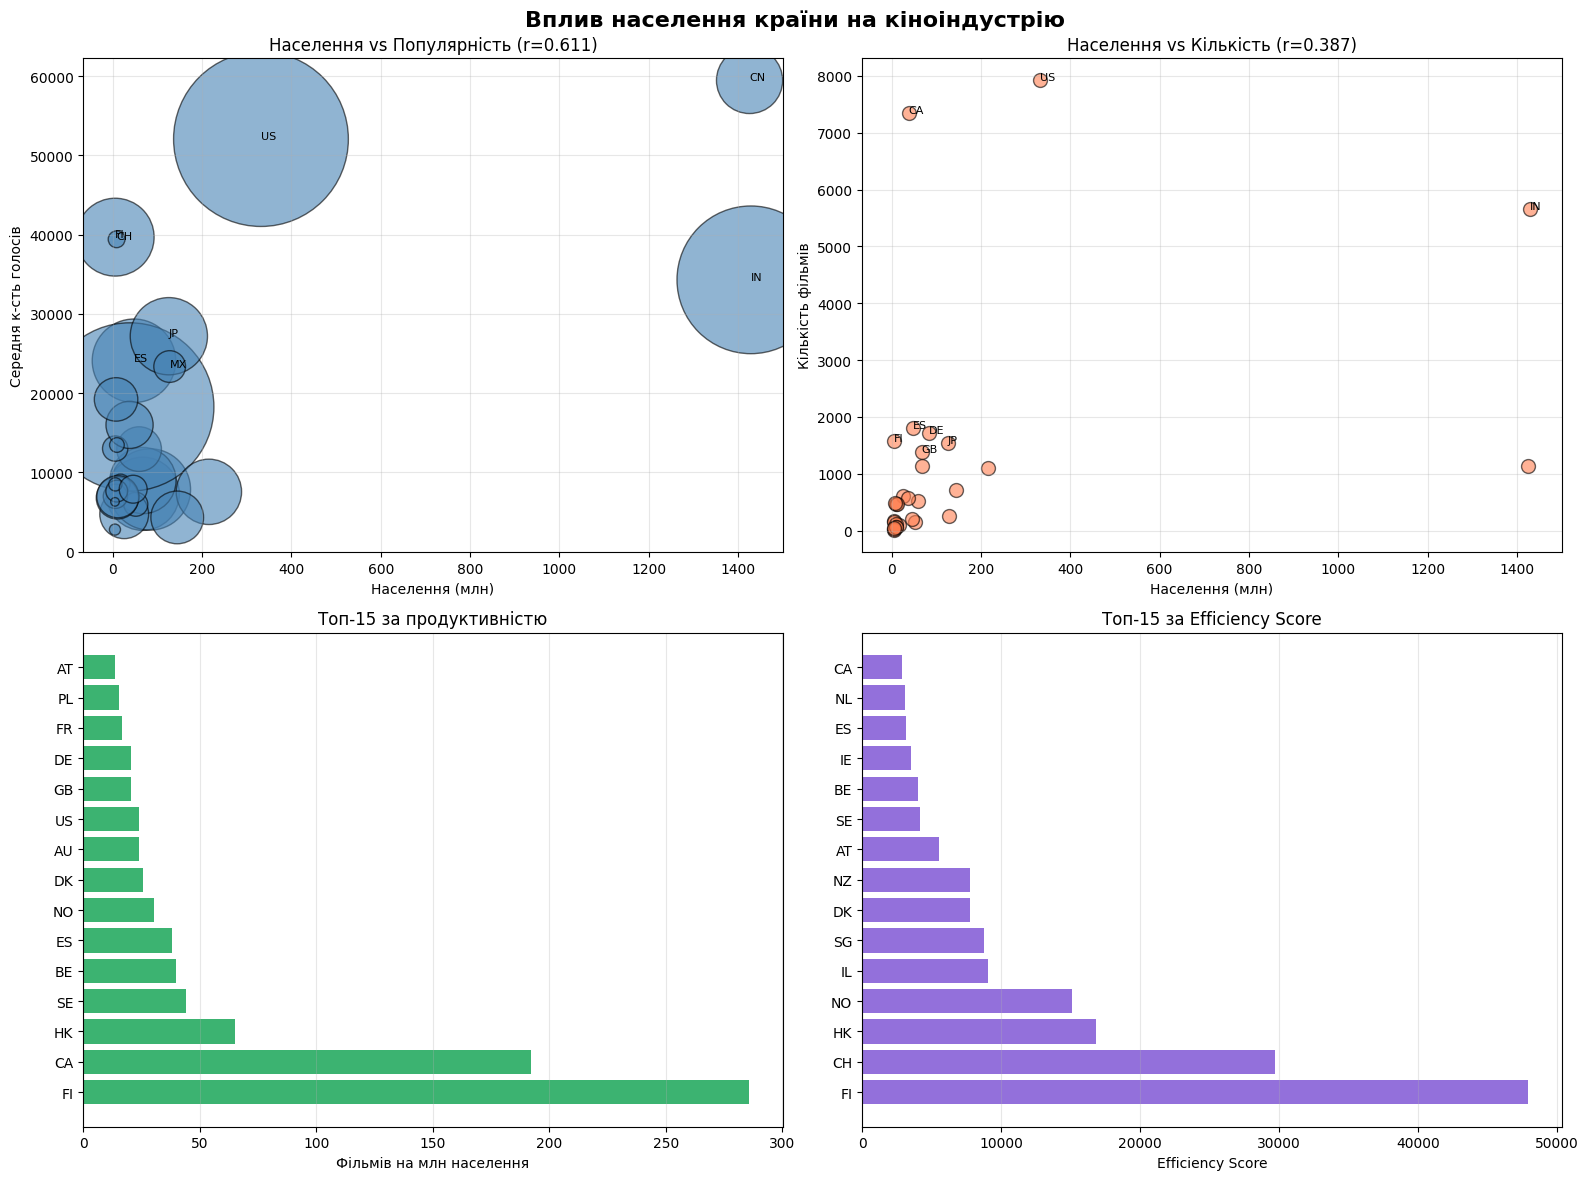

✅ Візуалізацію збережено


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Вплив населення країни на кіноіндустрію', fontsize=16, fontweight='bold')

# 1. Населення vs Популярність
ax1 = axes[0, 0]
ax1.scatter(films_pd['population_millions'], films_pd['avg_votes'],
           s=films_pd['num_films']*2, c='steelblue', alpha=0.6, edgecolors='black')
for idx, row in films_pd.nlargest(8, 'avg_votes').iterrows():
    ax1.annotate(row['country'], (row['population_millions'], row['avg_votes']), fontsize=8)
ax1.set_xlabel('Населення (млн)')
ax1.set_ylabel('Середня к-сть голосів')
ax1.set_title(f'Населення vs Популярність (r={corr_pop_votes:.3f})')
ax1.grid(True, alpha=0.3)

# 2. Населення vs Кількість фільмів
ax2 = axes[0, 1]
ax2.scatter(films_pd['population_millions'], films_pd['num_films'],
           s=100, c='coral', alpha=0.6, edgecolors='black')
for idx, row in films_pd.nlargest(8, 'num_films').iterrows():
    ax2.annotate(row['country'], (row['population_millions'], row['num_films']), fontsize=8)
ax2.set_xlabel('Населення (млн)')
ax2.set_ylabel('Кількість фільмів')
ax2.set_title(f'Населення vs Кількість (r={corr_pop_count:.3f})')
ax2.grid(True, alpha=0.3)

# 3. Фільмів на мільйон
ax3 = axes[1, 0]
top_eff = films_pd.nlargest(15, 'films_per_million')
ax3.barh(top_eff['country'], top_eff['films_per_million'], color='mediumseagreen')
ax3.set_xlabel('Фільмів на млн населення')
ax3.set_title('Топ-15 за продуктивністю')
ax3.grid(True, alpha=0.3, axis='x')

# 4. Efficiency Score
ax4 = axes[1, 1]
top_score = films_pd.nlargest(15, 'efficiency_score')
ax4.barh(top_score['country'], top_score['efficiency_score'], color='mediumpurple')
ax4.set_xlabel('Efficiency Score')
ax4.set_title('Топ-15 за Efficiency Score')
ax4.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('/app/visualizations/country_population_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Візуалізацію збережено")


## 6. Елітні хіти vs Масова продукція

**Бізнес-питання:** Чи робить країна БАГАТО середніх фільмів або МАЛО шедеврів?

### Стратегії кіновиробництва:
- **Quality over Quantity**: Мало фільмів, але високого рейтингу
- **Volume Strategy**: Багато фільмів, середня якість  
- **Elite Hits**: Високий % фільмів-блокбастерів (>100K votes)
- **Mass Production**: Великі обсяги, різна якість


In [11]:
# Аналіз розподілу якості фільмів по країнах
elite_analysis = films_with_ratings.groupBy("country").agg(
    F.count("tconst").alias("total_films"),
    
    # Елітні хіти (рейтинг > 8.0)
    F.sum(F.when(F.col("averageRating") >= 8.5, 1).otherwise(0)).alias("elite_films_count"),
    
    # Блокбастери (votes > 100,000)
    F.sum(F.when(F.col("numVotes") >= 100000, 1).otherwise(0)).alias("blockbuster_count"),
    
    # Високоякісні (рейтинг > 7.0)
    F.sum(F.when(F.col("averageRating") >= 7.0, 1).otherwise(0)).alias("high_quality_count"),
    
    # Середня якість (рейтинг 6.0-7.0)
    F.sum(F.when((F.col("averageRating") >= 6.0) & (F.col("averageRating") < 7.0), 1).otherwise(0)).alias("medium_quality_count"),
    
    # Низька якість (рейтинг < 6.0)
    F.sum(F.when(F.col("averageRating") < 6.0, 1).otherwise(0)).alias("low_quality_count"),
    
    # Статистика рейтингів
    F.avg("averageRating").alias("avg_rating"),
    F.stddev("averageRating").alias("rating_stddev"),
    F.max("averageRating").alias("max_rating"),
    F.min("averageRating").alias("min_rating")
).join(population_df, "country", "inner").filter(
    F.col("total_films") >= 50  # ⚠️ ФІЛЬТР: мінімум 50 фільмів для достовірної статистики
)

print(f"✅ Країн після фільтру (≥50 фільмів): {elite_analysis.count()}")

# Обчислюємо відсотки
elite_analysis = elite_analysis.withColumn(
    "elite_pct", (F.col("elite_films_count") / F.col("total_films") * 100)
).withColumn(
    "blockbuster_pct", (F.col("blockbuster_count") / F.col("total_films") * 100)
).withColumn(
    "high_quality_pct", (F.col("high_quality_count") / F.col("total_films") * 100)
).withColumn(
    "quality_score", 
    (F.col("elite_pct") * 3 + F.col("high_quality_pct")) / 4  # Зважений score
)

# Конвертуємо в Pandas
elite_pd = elite_analysis.toPandas()

print("="*80)
print("ЕЛІТНІ ХІТИ VS МАСОВА ПРОДУКЦІЯ")
print("="*80)
print("\n🏆 ТОП-10 країн за % ЕЛІТНИХ ФІЛЬМІВ (рейтинг ≥ 8.0):")
print("-"*80)
top_elite = elite_pd.nlargest(10, 'elite_pct')[['country', 'total_films', 'elite_films_count', 'elite_pct', 'avg_rating']]
for idx, row in top_elite.iterrows():
    print(f"{row['country']}: {row['elite_pct']:.1f}% ({row['elite_films_count']:.0f}/{row['total_films']:.0f} фільмів) - avg: {row['avg_rating']:.2f}")

print("\n\n💎 ТОП-10 країн за % БЛОКБАСТЕРІВ (votes ≥ 100K):")
print("-"*80)
top_blockbuster = elite_pd.nlargest(10, 'blockbuster_pct')[['country', 'total_films', 'blockbuster_count', 'blockbuster_pct']]
for idx, row in top_blockbuster.iterrows():
    print(f"{row['country']}: {row['blockbuster_pct']:.1f}% ({row['blockbuster_count']:.0f}/{row['total_films']:.0f} фільмів)")

print("\n\n📊 ТОП-10 країн за ЯКІСНИМ СКОРОМ (зважений):")
print("-"*80)
top_quality = elite_pd.nlargest(10, 'quality_score')[['country', 'total_films', 'quality_score', 'elite_pct', 'high_quality_pct']]
for idx, row in top_quality.iterrows():
    print(f"{row['country']}: Score={row['quality_score']:.1f} (Elite: {row['elite_pct']:.1f}%, High: {row['high_quality_pct']:.1f}%)")

print("\n\n🏭 ТОП-10 за ОБСЯГОМ (масова продукція):")
print("-"*80)
top_volume = elite_pd.nlargest(10, 'total_films')[['country', 'total_films', 'elite_pct', 'avg_rating', 'rating_stddev']]
for idx, row in top_volume.iterrows():
    print(f"{row['country']}: {row['total_films']:.0f} фільмів - Elite: {row['elite_pct']:.1f}%, Avg: {row['avg_rating']:.2f} (σ={row['rating_stddev']:.2f})")


✅ Країн після фільтру (≥50 фільмів): 28


ЕЛІТНІ ХІТИ VS МАСОВА ПРОДУКЦІЯ

🏆 ТОП-10 країн за % ЕЛІТНИХ ФІЛЬМІВ (рейтинг ≥ 8.0):
--------------------------------------------------------------------------------
IN: 2.3% (133/5691 фільмів) - avg: 6.38
CH: 1.6% (1/61 фільмів) - avg: 6.50
AU: 1.5% (10/650 фільмів) - avg: 6.08
GB: 1.2% (17/1426 фільмів) - avg: 6.10
AR: 1.0% (2/193 фільмів) - avg: 6.33
JP: 0.7% (11/1535 фільмів) - avg: 6.39
NO: 0.6% (1/170 фільмів) - avg: 6.41
FI: 0.6% (9/1533 фільмів) - avg: 6.64
IT: 0.6% (3/543 фільмів) - avg: 6.13
US: 0.5% (41/7862 фільмів) - avg: 6.10


💎 ТОП-10 країн за % БЛОКБАСТЕРІВ (votes ≥ 100K):
--------------------------------------------------------------------------------
CN: 17.6% (197/1120 фільмів)
US: 12.6% (989/7862 фільмів)
FI: 9.1% (140/1533 фільмів)
IN: 7.3% (418/5691 фільмів)
CH: 6.6% (4/61 фільмів)
ES: 6.5% (120/1851 фільмів)
JP: 6.3% (96/1535 фільмів)
MX: 4.5% (11/242 фільмів)
HK: 4.1% (20/491 фільмів)
PL: 3.8% (21/552 фільмів)


📊 ТОП-10 країн за ЯКІСНИМ СКОРОМ (зважений):
---

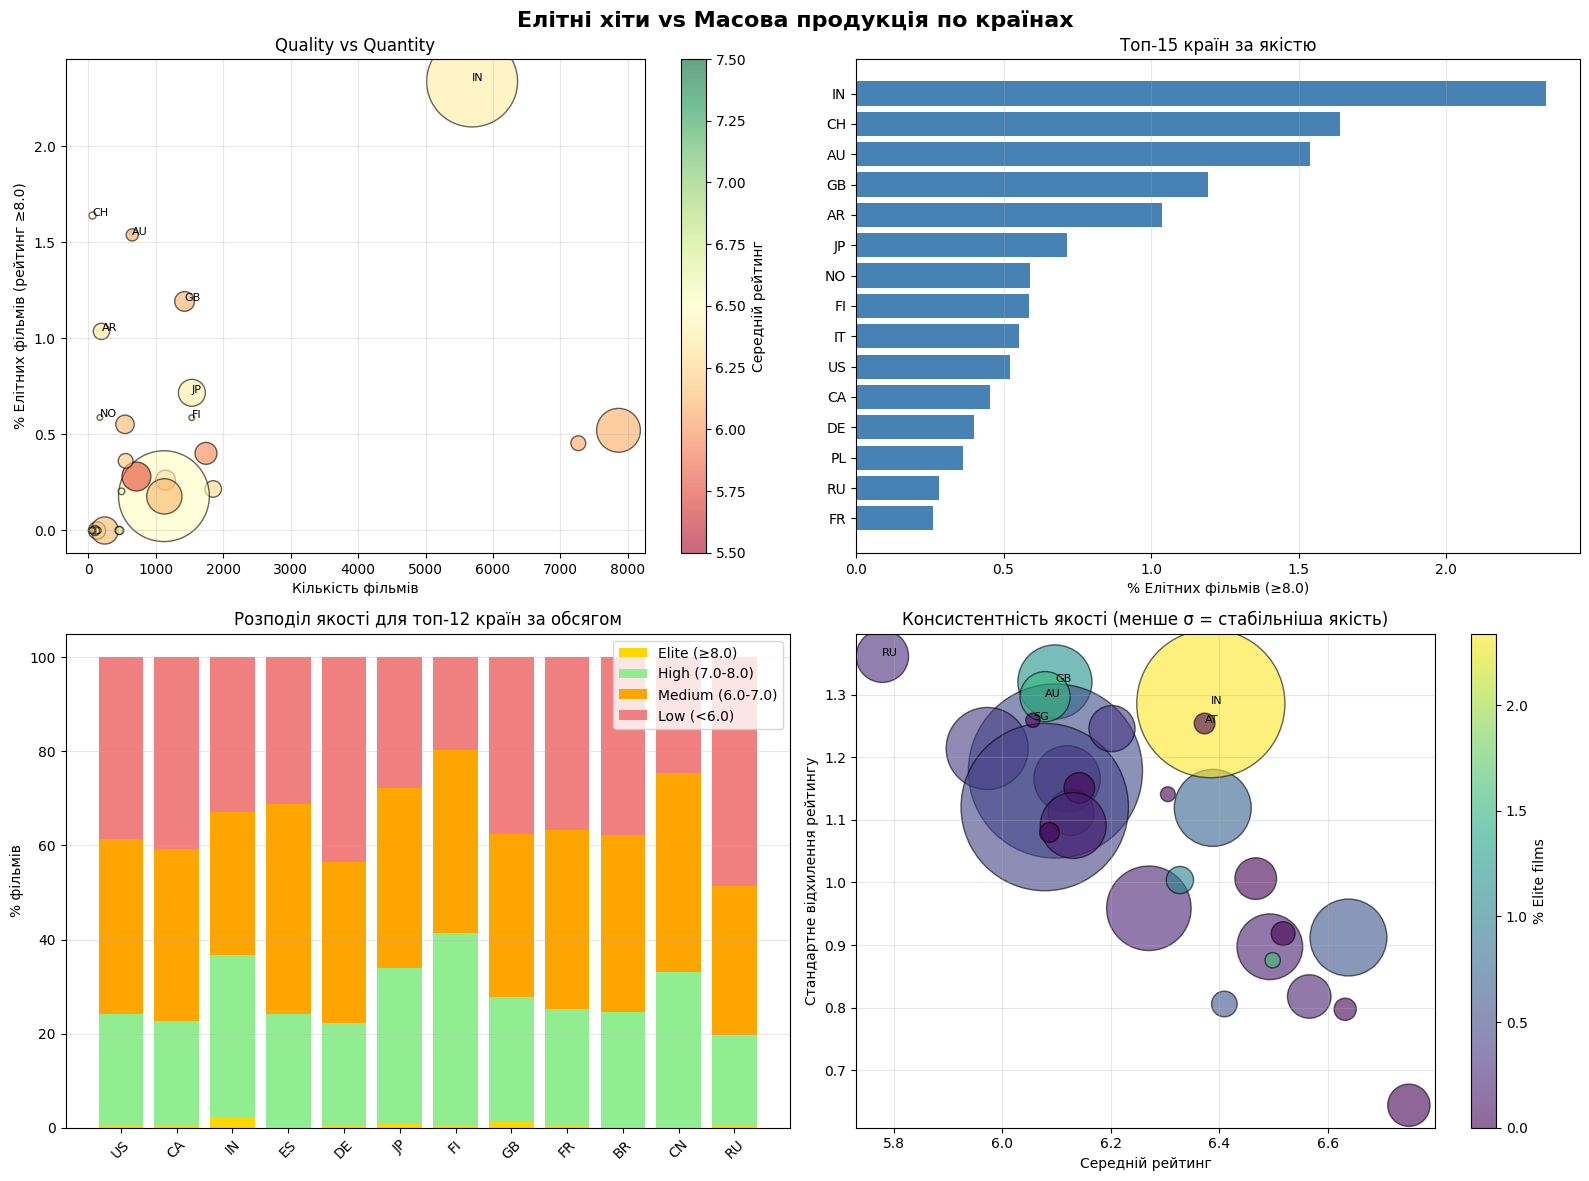


✅ Візуалізацію збережено: visualizations/elite_vs_mass_production.png


In [12]:
# Візуалізація: Елітні хіти vs Масова продукція
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Елітні хіти vs Масова продукція по країнах', fontsize=16, fontweight='bold')

# 1. Scatter: Кількість vs % елітних фільмів
ax1 = axes[0, 0]
scatter1 = ax1.scatter(elite_pd['total_films'], elite_pd['elite_pct'],
                      s=elite_pd['population_millions']*3, 
                      c=elite_pd['avg_rating'], 
                      cmap='RdYlGn', alpha=0.6, edgecolors='black', vmin=5.5, vmax=7.5)
for idx, row in elite_pd.nlargest(8, 'elite_pct').iterrows():
    ax1.annotate(row['country'], (row['total_films'], row['elite_pct']), fontsize=8)
ax1.set_xlabel('Кількість фільмів')
ax1.set_ylabel('% Елітних фільмів (рейтинг ≥8.0)')
ax1.set_title('Quality vs Quantity')
ax1.grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=ax1, label='Середній рейтинг')

# 2. Bar: Топ-15 за % елітних фільмів
ax2 = axes[0, 1]
top15_elite = elite_pd.nlargest(15, 'elite_pct').sort_values('elite_pct')
colors = ['gold' if x > 10 else 'steelblue' for x in top15_elite['elite_pct']]
ax2.barh(top15_elite['country'], top15_elite['elite_pct'], color=colors)
ax2.set_xlabel('% Елітних фільмів (≥8.0)')
ax2.set_title('Топ-15 країн за якістю')
ax2.grid(True, alpha=0.3, axis='x')

# 3. Розподіл якості (stacked bar)
ax3 = axes[1, 0]
top12_volume = elite_pd.nlargest(12, 'total_films')
# Обчислюємо відсотки для стеку
top12_volume['elite_pct_abs'] = top12_volume['elite_films_count'] / top12_volume['total_films'] * 100
top12_volume['high_pct_abs'] = (top12_volume['high_quality_count'] - top12_volume['elite_films_count']) / top12_volume['total_films'] * 100
top12_volume['med_pct_abs'] = top12_volume['medium_quality_count'] / top12_volume['total_films'] * 100
top12_volume['low_pct_abs'] = top12_volume['low_quality_count'] / top12_volume['total_films'] * 100

x = range(len(top12_volume))
ax3.bar(x, top12_volume['elite_pct_abs'], label='Elite (≥8.0)', color='gold')
ax3.bar(x, top12_volume['high_pct_abs'], bottom=top12_volume['elite_pct_abs'], 
        label='High (7.0-8.0)', color='lightgreen')
ax3.bar(x, top12_volume['med_pct_abs'], 
        bottom=top12_volume['elite_pct_abs'] + top12_volume['high_pct_abs'],
        label='Medium (6.0-7.0)', color='orange')
ax3.bar(x, top12_volume['low_pct_abs'],
        bottom=top12_volume['elite_pct_abs'] + top12_volume['high_pct_abs'] + top12_volume['med_pct_abs'],
        label='Low (<6.0)', color='lightcoral')
ax3.set_xticks(x)
ax3.set_xticklabels(top12_volume['country'], rotation=45)
ax3.set_ylabel('% фільмів')
ax3.set_title('Розподіл якості для топ-12 країн за обсягом')
ax3.legend(loc='upper right')
ax3.grid(True, alpha=0.3, axis='y')

# 4. Scatter: Стандартне відхилення vs Середній рейтинг
ax4 = axes[1, 1]
scatter4 = ax4.scatter(elite_pd['avg_rating'], elite_pd['rating_stddev'],
                      s=elite_pd['total_films']*2,
                      c=elite_pd['elite_pct'], cmap='viridis',
                      alpha=0.6, edgecolors='black')
for idx, row in elite_pd.nlargest(6, 'rating_stddev').iterrows():
    ax4.annotate(row['country'], (row['avg_rating'], row['rating_stddev']), fontsize=8)
ax4.set_xlabel('Середній рейтинг')
ax4.set_ylabel('Стандартне відхилення рейтингу')
ax4.set_title('Консистентність якості (менше σ = стабільніша якість)')
ax4.grid(True, alpha=0.3)
plt.colorbar(scatter4, ax=ax4, label='% Elite films')

plt.tight_layout()
plt.savefig('/app/visualizations/elite_vs_mass_production.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Візуалізацію збережено: visualizations/elite_vs_mass_production.png")


## 7. Жанрові преференції країн

**Бізнес-питання:** Які жанри є "спеціалізацією" для кожної країни?

### Мета аналізу:
- Знайти **топ-3 жанри** для кожної країни
- Виявити **унікальні спеціалізації** (країна робить жанр краще за інших)
- Порівняти **жанрове різноманіття** між країнами
- Визначити **успішні жанри** (рейтинг + популярність)


In [13]:
# Підготовка даних з жанрами
# genres у форматі "Action,Drama,Thriller" - треба розділити

# Спочатку визначаємо країни з >= 50 фільмів
countries_with_enough_films = films_with_ratings.groupBy("country").agg(
    F.count("tconst").alias("total_films")
).filter(
    F.col("total_films") >= 50
).select("country")

print(f"✅ Країн з ≥50 фільмів: {countries_with_enough_films.count()}")

# Розділяємо жанри (explode) тільки для країн з достатньою кількістю фільмів
films_with_genres = films_with_ratings.join(
    countries_with_enough_films, "country", "inner"
).filter(
    F.col("genres").isNotNull()
).select(
    F.col("tconst"),
    F.col("country"),
    F.col("numVotes"),
    F.col("averageRating"),
    F.explode(F.split(F.col("genres"), ",")).alias("genre")
).filter(
    F.col("genre") != "\\\\N"
)

print(f"✅ Розділено фільми на окремі жанри: {films_with_genres.count():,} записів")
print(f"   Унікальних жанрів: {films_with_genres.select('genre').distinct().count()}")

# Аналіз по країнах і жанрах
genre_by_country = films_with_genres.groupBy("country", "genre").agg(
    F.count("tconst").alias("film_count"),
    F.avg("averageRating").alias("avg_rating"),
    F.avg("numVotes").alias("avg_votes"),
    F.sum("numVotes").alias("total_votes")
).join(
    population_df, "country", "inner"
)

# Додаємо метрики
genre_by_country = genre_by_country.withColumn(
    "genre_score",
    (F.col("avg_rating") * F.col("avg_votes")) / 1000  # Нормалізований score
).withColumn(
    "films_per_million",
    F.col("film_count") / F.col("population_millions")
)

# Конвертуємо в Pandas
genre_pd = genre_by_country.toPandas()

print("\n" + "="*80)
print("ЖАНРОВІ ПРЕФЕРЕНЦІЇ КРАЇН")
print("="*80)

# Топ-3 жанри для кожної країни за кількістю
print("\n📊 ТОП-3 ЖАНРИ ЗА КІЛЬКІСТЮ для основних країн:")
print("-"*80)
for country in ['US', 'GB', 'FR', 'DE', 'JP', 'IN', 'KR', 'CN']:
    country_data = genre_pd[genre_pd['country'] == country].nlargest(3, 'film_count')
    if len(country_data) > 0:
        print(f"\n{country}:")
        for idx, row in country_data.iterrows():
            print(f"  {row['genre']:15} - {row['film_count']:4.0f} фільмів (рейтинг: {row['avg_rating']:.2f})")

# Топ-3 жанри за рейтингом (мінімум 10 фільмів)
print("\n\n⭐ ТОП-3 ЖАНРИ ЗА РЕЙТИНГОМ (мін. 10 фільмів):")
print("-"*80)
for country in ['US', 'GB', 'FR', 'DE', 'JP', 'IN']:
    country_data = genre_pd[(genre_pd['country'] == country) & (genre_pd['film_count'] >= 10)].nlargest(3, 'avg_rating')
    if len(country_data) > 0:
        print(f"\n{country}:")
        for idx, row in country_data.iterrows():
            print(f"  {row['genre']:15} - рейтинг: {row['avg_rating']:.2f} ({row['film_count']:3.0f} фільмів)")

# Найпопулярніші жанри (за votes)
print("\n\n💎 ТОП-3 ЖАНРИ ЗА ПОПУЛЯРНІСТЮ (avg votes):")
print("-"*80)
for country in ['US', 'GB', 'JP', 'KR']:
    country_data = genre_pd[(genre_pd['country'] == country) & (genre_pd['film_count'] >= 5)].nlargest(3, 'avg_votes')
    if len(country_data) > 0:
        print(f"\n{country}:")
        for idx, row in country_data.iterrows():
            print(f"  {row['genre']:15} - {row['avg_votes']:,.0f} votes (рейтинг: {row['avg_rating']:.2f})")


✅ Країн з ≥50 фільмів: 51


✅ Розділено фільми на окремі жанри: 107,924 записів


   Унікальних жанрів: 26



ЖАНРОВІ ПРЕФЕРЕНЦІЇ КРАЇН

📊 ТОП-3 ЖАНРИ ЗА КІЛЬКІСТЮ для основних країн:
--------------------------------------------------------------------------------

US:
  Drama           - 3804 фільмів (рейтинг: 6.40)
  Comedy          - 2668 фільмів (рейтинг: 6.02)
  Horror          - 1500 фільмів (рейтинг: 5.25)

GB:
  Drama           -  702 фільмів (рейтинг: 6.35)
  Comedy          -  425 фільмів (рейтинг: 6.06)
  Thriller        -  232 фільмів (рейтинг: 5.53)

FR:
  Drama           -  639 фільмів (рейтинг: 6.47)
  Comedy          -  365 фільмів (рейтинг: 6.10)
  Romance         -  184 фільмів (рейтинг: 6.42)

DE:
  Drama           -  952 фільмів (рейтинг: 6.29)
  Comedy          -  572 фільмів (рейтинг: 5.94)
  Thriller        -  302 фільмів (рейтинг: 5.47)

JP:
  Drama           -  830 фільмів (рейтинг: 6.66)
  Action          -  395 фільмів (рейтинг: 6.08)
  Comedy          -  362 фільмів (рейтинг: 6.33)

IN:
  Drama           - 3415 фільмів (рейтинг: 6.59)
  Action          - 1749 фільм

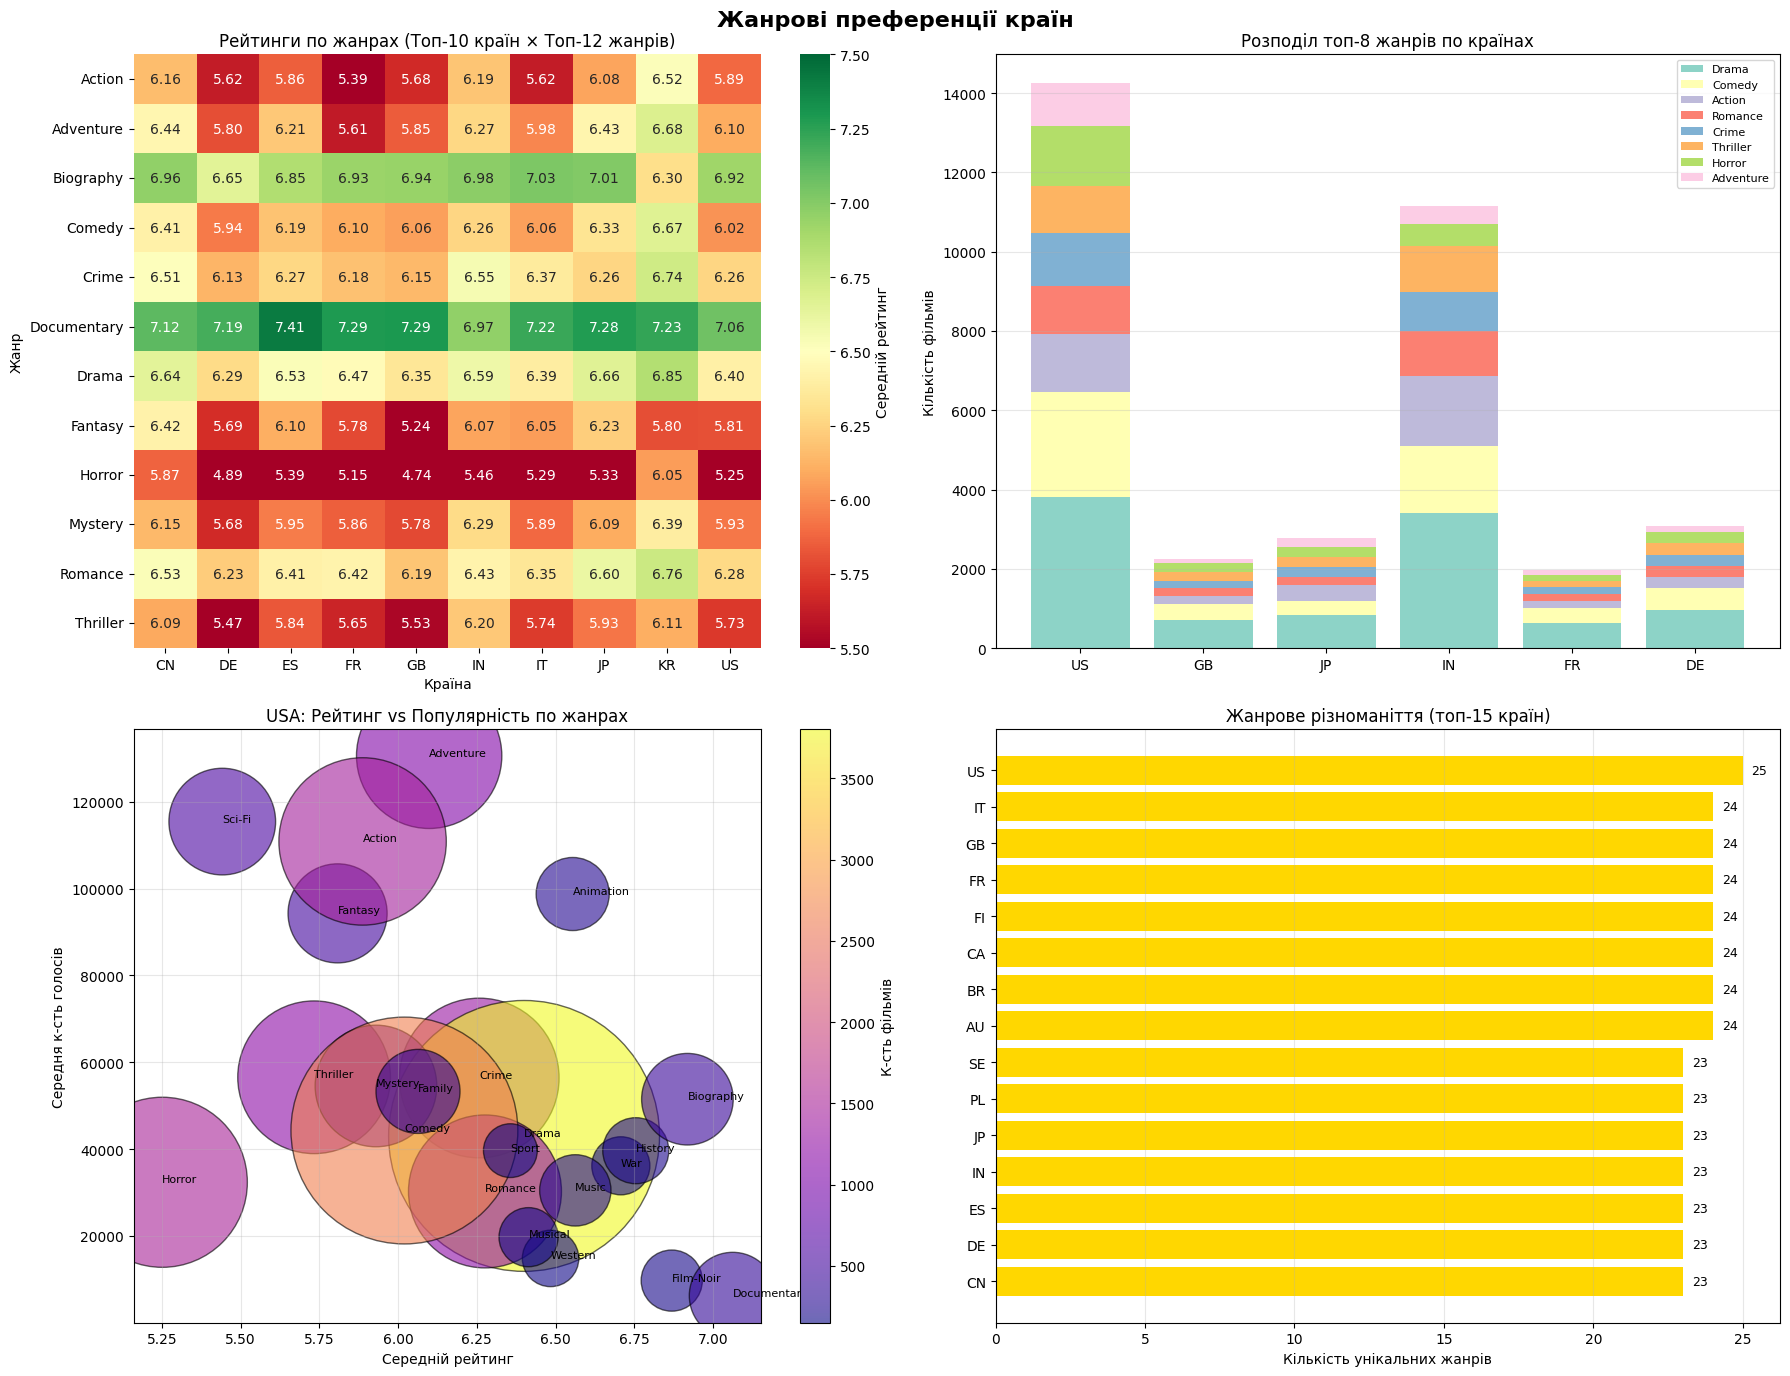


✅ Візуалізацію збережено: visualizations/genre_preferences.png


In [14]:
# Візуалізація жанрових преференцій
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Жанрові преференції країн', fontsize=16, fontweight='bold')

# 1. Heatmap: Топ жанри для топ країн
ax1 = axes[0, 0]
# Створюємо pivot table
top_countries = ['US', 'GB', 'FR', 'DE', 'JP', 'IN', 'KR', 'CN', 'ES', 'IT']
top_genres = genre_pd.groupby('genre')['film_count'].sum().nlargest(12).index.tolist()

heatmap_data = genre_pd[
    (genre_pd['country'].isin(top_countries)) & 
    (genre_pd['genre'].isin(top_genres))
].pivot(index='genre', columns='country', values='avg_rating')

sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdYlGn', 
            center=6.5, vmin=5.5, vmax=7.5, ax=ax1, cbar_kws={'label': 'Середній рейтинг'})
ax1.set_title('Рейтинги по жанрах (Топ-10 країн × Топ-12 жанрів)')
ax1.set_xlabel('Країна')
ax1.set_ylabel('Жанр')

# 2. Stacked bar: Розподіл жанрів по країнах
ax2 = axes[0, 1]
countries_for_stack = ['US', 'GB', 'JP', 'IN', 'FR', 'DE']
genres_for_stack = genre_pd.groupby('genre')['film_count'].sum().nlargest(8).index.tolist()

stack_data = {}
for genre in genres_for_stack:
    stack_data[genre] = []
    for country in countries_for_stack:
        val = genre_pd[(genre_pd['country'] == country) & (genre_pd['genre'] == genre)]['film_count'].sum()
        stack_data[genre].append(val)

# Малюємо stacked bar
bottom = [0] * len(countries_for_stack)
colors_palette = plt.cm.Set3(range(len(genres_for_stack)))
for i, genre in enumerate(genres_for_stack):
    ax2.bar(countries_for_stack, stack_data[genre], bottom=bottom, 
            label=genre, color=colors_palette[i])
    bottom = [bottom[j] + stack_data[genre][j] for j in range(len(countries_for_stack))]

ax2.set_ylabel('Кількість фільмів')
ax2.set_title('Розподіл топ-8 жанрів по країнах')
ax2.legend(loc='upper right', fontsize=8)
ax2.grid(True, alpha=0.3, axis='y')

# 3. Scatter: Рейтинг vs Популярність по жанрах (для США)
ax3 = axes[1, 0]
us_genres = genre_pd[(genre_pd['country'] == 'US') & (genre_pd['film_count'] >= 20)]
scatter3 = ax3.scatter(us_genres['avg_rating'], us_genres['avg_votes'],
                      s=us_genres['film_count']*10,
                      c=us_genres['film_count'], cmap='plasma',
                      alpha=0.6, edgecolors='black')
for idx, row in us_genres.iterrows():
    ax3.annotate(row['genre'], (row['avg_rating'], row['avg_votes']), fontsize=8)
ax3.set_xlabel('Середній рейтинг')
ax3.set_ylabel('Середня к-сть голосів')
ax3.set_title('USA: Рейтинг vs Популярність по жанрах')
ax3.grid(True, alpha=0.3)
plt.colorbar(scatter3, ax=ax3, label='К-сть фільмів')

# 4. Bar: Жанрове різноманіття (кількість унікальних жанрів)
ax4 = axes[1, 1]
genre_diversity = genre_pd.groupby('country').agg({
    'genre': 'nunique',
    'film_count': 'sum'
}).reset_index()
genre_diversity.columns = ['country', 'unique_genres', 'total_films']
genre_diversity['diversity_score'] = genre_diversity['unique_genres'] / genre_diversity['total_films'] * 100

top_diverse = genre_diversity.nlargest(15, 'unique_genres').sort_values('unique_genres')
colors_div = ['gold' if x > 15 else 'steelblue' for x in top_diverse['unique_genres']]
ax4.barh(top_diverse['country'], top_diverse['unique_genres'], color=colors_div)
ax4.set_xlabel('Кількість унікальних жанрів')
ax4.set_title('Жанрове різноманіття (топ-15 країн)')
ax4.grid(True, alpha=0.3, axis='x')

# Додаємо значення на барах
for i, (idx, row) in enumerate(top_diverse.iterrows()):
    ax4.text(row['unique_genres'] + 0.3, i, f"{row['unique_genres']:.0f}", 
             va='center', fontsize=9)

plt.tight_layout()
plt.savefig('/app/visualizations/genre_preferences.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Візуалізацію збережено: visualizations/genre_preferences.png")
